In [1]:
pip install pandas numpy matplotlib seaborn scipy requests jupyter biopython

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

# Importing the data from GWAS Catalogue
gwas = pd.read_csv(
    "../data/Breast_Cancer_GWAS.tsv",
    sep="\t"
)

# Keeping only the SNP with pathological breast cancer and a relevant p-value
breast = gwas[
    (gwas["traitName"].str.contains("breast cancer", case=False)) &
    (gwas["pValue"] < 5e-8)
]

# Splitting the location into chromosome and base pair
breast["Chromosome"] = breast["locations"].str.split(":").str[0]
breast["BasePair"] = breast["locations"].str.split(":").str[1]

# Renaming the riskAllele as SNP
breast["SNP"] = breast["riskAllele"]
breast.head()

/var/folders/mf/pqdx96c55v1g4nt556l799l80000gn/T/ipykernel_15262/4071924075.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  breast["Chromosome"] = breast["locations"].str.split(":").str[0]
/var/folders/mf/pqdx96c55v1g4nt556l799l80000gn/T/ipykernel_15262/4071924075.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  breast["BasePair"] = breast["locations"].str.split(":").str[1]
/var/folders/mf/pqdx96c55v1g4nt556l799l80000gn/T/ipykernel_15262/4071924075.py:20: SettingWithCopyWarning: 
A value is trying 

,riskAllele,pValue,pValueAnnotation,riskFrequency,orValue,beta,ci,mappedGenes,traitName,efoTraits,bgTraits,accessionId,locations,pubmedId,author,Chromosome,BasePair,SNP
0,rs8030394-?,1.000000e-08,-,NR,2.47,-,[1.81-3.37],THSD4,15-year breast cancer-specific survival (ER po...,"Her2-receptor negative breast cancer,estrogen-...",-,GCST90029047,15:71344902,34407845,Morra A,15,71344902,rs8030394-?
1,rs62192052-?,3.000000e-09,-,NR,0.15,-,[0.08-0.28],DNER,15-year breast cancer-specific survival (ER po...,"Her2-receptor negative breast cancer,estrogen-...",-,GCST90029048,2:229507632,34407845,Morra A,2,229507632,rs62192052-?
2,rs13258434-G,2.000000e-09,-,NR,-,0.028 unit increase,[0.018-0.038],"LINC02845,NACA4P",Breast cancer subtype (triple negative vs lumi...,"triple-negative breast carcinoma,Her2-receptor...",-,GCST90446472,8:101379857,38832928,Sun X,8,101379857,rs13258434-G
3,rs1243184-T,2.000000e-08,-,NR,-,0.025 unit increase,[0.017-0.033],MLLT10,Breast cancer subtype (triple negative vs lumi...,"triple-negative breast carcinoma,Her2-receptor...",-,GCST90446472,10:21643008,38832928,Sun X,10,21643008,rs1243184-T
4,rs6663303-C,1.000000e-08,-,NR,-,0.03 unit increase,[0.016-0.044],LGR6,Breast cancer subtype (HER2-enriched-like vs l...,"HER2 positive breast carcinoma,luminal A breas...",-,GCST90446469,1:202208798,38832928,Sun X,1,202208798,rs6663303-C


In [10]:
# Checking the number of SNPs
n_variants = breast["riskAllele"].nunique()
print("number of SNP: ",n_variants)

# Creating a table with the number of SNPs divided by Chromosome number
import pandas as pd

# Create the chromosome count table
chromosome_table = (
    breast["Chromosome"]
    .value_counts()
    .rename_axis("Chromosome")
    .reset_index(name="Number_of_SNPs")
)

# Create a sorting key:
# Numeric chromosomes keep their number.
# Non-numeric chromosomes (X, Y, MT, -, etc.) become NaN.
chromosome_table["sort_key"] = pd.to_numeric(
    chromosome_table["Chromosome"],
    errors="coerce"
)

# Sort by the numeric key (NaN values automatically go to the bottom)
chromosome_table = (
    chromosome_table
    .sort_values(by="sort_key", na_position="last")
    .drop(columns="sort_key")
    .reset_index(drop=True)
)

print(chromosome_table)

number of SNP:  1353
   Chromosome  Number_of_SNPs
0           1             127
1           2             136
2           3             100
3           4              48
4           5             205
5           6             146
6           7              54
7           8             103
8           9              64
9          10             161
10         11              91
11         12              85
12         13              14
13         14              48
14         15              19
15         16             101
16         17              80
17         18              38
18         19              72
19         20              17
20         21              23
21         22              75
22          -              63
23          X               1


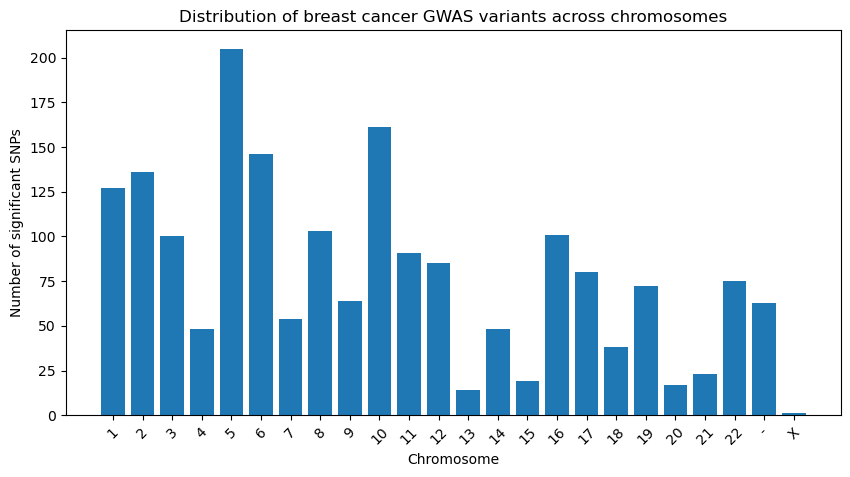

In [11]:
import matplotlib.pyplot as plt

# Formatting the graph representing the number of SNPs per each chromosome
plt.figure(figsize=(10,5))

plt.bar(
    chromosome_table["Chromosome"].astype(str),
    chromosome_table["Number_of_SNPs"]
)

plt.xlabel("Chromosome")
plt.ylabel("Number of significant SNPs")
plt.title(
    "Distribution of breast cancer GWAS variants across chromosomes"
)

plt.xticks(rotation=45)

plt.show()

In [24]:
import numpy as np
import pandas as pd

manhattan_data = breast.copy()

# Clean chromosomes
manhattan_data["Chromosome"] = manhattan_data["Chromosome"].astype(str)

# Clean base pair position
manhattan_data["BasePair"] = pd.to_numeric(
    manhattan_data["BasePair"],
    errors="coerce"
)

# Remove missing positions
manhattan_data = manhattan_data.dropna(
    subset=["BasePair", "Chromosome"]
)

# Order chromosomes correctly
chrom_order = [
    str(i) for i in range(1, 23)
] + ["X"]

chromosomes = [
    chrom for chrom in chrom_order
    if chrom in manhattan_data["Chromosome"].unique()
]

# Sort
manhattan_data["Chromosome"] = pd.Categorical(
    manhattan_data["Chromosome"],
    categories=chromosomes,
    ordered=True
)

manhattan_data = manhattan_data.sort_values(
    ["Chromosome", "BasePair"]
).copy()

# Making BasePair and Chromosome numeric values
manhattan_data["BasePair"] = pd.to_numeric(
    manhattan_data["BasePair"],
    errors="coerce"
)
manhattan_data["Chromosome"] = pd.to_numeric(
    manhattan_data["Chromosome"],
    errors="coerce"
)
chromosomes = sorted(
    manhattan_data["Chromosome"].unique()
)

# Creates an empty column needed for the x-axis
manhattan_data["BP_cum_equal"] = 0

# Creates an empty dictionary
chrom_centers = {}

for i, chrom in enumerate(chromosomes):

    # Creates a true/false filter to check chromosome vs loop iteration
    mask = manhattan_data["Chromosome"] == chrom
    
    # Get chromosome length through the biggest SNP in the data
    chrom_length = (
        manhattan_data.loc[mask, "BasePair"].max()
    )
    
    # Scale SNP according to chromosome length: between 0 and 1
    scaled_position = (
        manhattan_data.loc[mask, "BasePair"] 
        / chrom_length
    )
    
    # Put each chromosome in its own equally-sized block
    manhattan_data.loc[mask, "BP_cum_equal"] = (
        i + scaled_position
    )
    
    # Position of chromosome label
    chrom_centers[chrom] = i + 0.5

/var/folders/mf/pqdx96c55v1g4nt556l799l80000gn/T/ipykernel_15262/2245079711.py:79: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00793707 0.00793708 0.01497605 0.03786898 0.04342626 0.04342626
 0.04343704 0.04343704 0.04343704 0.04343704 0.04343704 0.04343704
 0.04343704 0.04356027 0.04368213 0.04368213 0.06477465 0.06620587
 0.07640787 0.07640787 0.09161486 0.13823097 0.16915949 0.16915949
 0.17228873 0.182122   0.19074322 0.19074322 0.19074322 0.20829438
 0.21082455 0.21086213 0.36099222 0.36255382 0.36255382 0.3636788
 0.36374996 0.38859519 0.38866041 0.45315361 0.45328771 0.45346609
 0.45349585 0.46979922 0.47092573 0.4709361  0.4709361  0.4709361
 0.4709361  0.48657184 0.48657184 0.49589546 0.49620959 0.49631447
 0.50077052 0.50249445 0.50249445 0.50249445 0.50249445 0.50249445
 0.50249445 0.50249445 0.50249445 0.50249445 0.50249445 0.50314109
 0.60251271 0.60275982 0.60275982 0.60275982 0.619894

In [28]:
import numpy as np
import pandas as pd

manhattan_data = breast.copy()

# Clean columns
manhattan_data["Chromosome"] = manhattan_data["Chromosome"].astype(str)
manhattan_data["BasePair"] = pd.to_numeric(
    manhattan_data["BasePair"],
    errors="coerce"
)

# Remove rows with missing positions/chromosomes
manhattan_data = manhattan_data.dropna(
    subset=["Chromosome", "BasePair"]
)

# Define chromosome order
chromosomes = [
    str(i) for i in range(1, 23)
] + ["X"]

# Apply chromosome order
manhattan_data["Chromosome"] = pd.Categorical(
    manhattan_data["Chromosome"],
    categories=chromosomes,
    ordered=True
)

# Sort SNPs
manhattan_data = manhattan_data.sort_values(
    ["Chromosome", "BasePair"]
).copy()

# Create x-axis coordinate column
manhattan_data["BP_cum_equal"] = 0.0

# Store chromosome label positions
chrom_centers = {}

for i, chrom in enumerate(chromosomes):

    mask = manhattan_data["Chromosome"] == chrom

    # Skip chromosomes not present in the dataset
    if mask.sum() == 0:
        continue

    chrom_length = manhattan_data.loc[
        mask, "BasePair"
    ].max()

    scaled_position = (
        manhattan_data.loc[mask, "BasePair"]
        / chrom_length
    )

    manhattan_data.loc[
        mask, "BP_cum_equal"
    ] = i + scaled_position

    chrom_centers[chrom] = i + 0.5

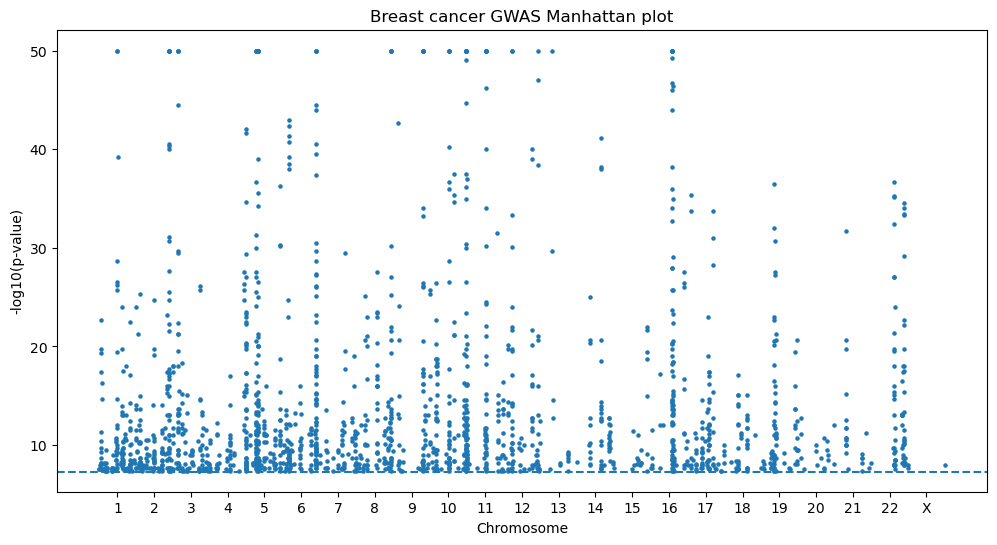

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Remove zero p-values (otherwise -log10(0) = infinity)
manhattan_data = manhattan_data[
    manhattan_data["pValue"] > 0
].copy()

# Calculate -log10(p)
manhattan_data["minus_log10_p"] = (
    -np.log10(manhattan_data["pValue"])
)

# Avoid extreme values dominating the plot
manhattan_data["minus_log10_p"] = (
    manhattan_data["minus_log10_p"]
    .clip(upper=50)
)

# Plotting the figure
plt.figure(figsize=(12,6))

plt.scatter(
    manhattan_data["BP_cum_equal"],
    manhattan_data["minus_log10_p"],
    s=5
)

plt.axhline(
    -np.log10(5e-8),
    linestyle="--"
)

plt.xticks(
    list(chrom_centers.values()),
    list(chrom_centers.keys())
)

plt.xlabel("Chromosome")
plt.ylabel("-log10(p-value)")
plt.title(
    "Breast cancer GWAS Manhattan plot"
)

plt.show()